# Przekleństwo wymiarowości

<div style="display: flex; justify-content: center;">
<img src=".//Images//curse_of_dimensionality_watercolor.png" alt="Przekleństwo wielowymiarowości" width="600" height="200" style="margin: 10px;"/>
</div>

Przekleństwo wymiarowości dotyczy problemu wykładniczego wzrostu danych w problemach związanych z uczeniem maszynowym. Oznacza to, że im większy wymiar, tym znacznie więcej danych potrzebujemy. Dodatkowo oprócz potrzeby coraz większych ilości danych, to wykładniczo rośnie liczba możliwych wariantów, co znacznie zwiększa złożoność obliczeniową naszych algorytmów.

Redukcja wymiaru jest to proces przekształcający pierwotny zbiór danych w zbiór o mniejszej liczbie wymiarów, zachowując przy tym informacje, które te dane ze sobą niosą.

Najczęściej stosowane metody: 

**a)** Metody oparte o szukanie czynników pomiędzy wymiarami (components / factor base):

* Principal Component Analysis (PCA) – redukuje wymiarowość poprzez liniowe kombinacje zmiennych maksymalizujące wariancję.
* Independent Component Analysis (ICA) – wydziela komponenty wzajemnie statystycznie niezależne.
* Factor Analysis – modeluje zmienność poprzez ukryte czynniki wyjaśniające wspólne korelacje zmiennych.

**b)** Metody oparte o rzutowanie jednego wymiaru na inny (Projection base):

* t-SNE – nieliniowa metoda rzutowania danych wysokowymiarowych na przestrzeń 2D/3D przy zachowaniu lokalnych odległości.
* UMAP – nieliniowa metoda rzutowania, która zachowuje zarówno lokalną, jak i globalną strukturę danych.
* Autoenkodery – sieci neuronowe uczące się kodowania i rekonstrukcji danych, umożliwiające kompresję wymiarów.

## Analiza składowych głównych (PCA) 

**PCA** (**Principal Component Analysis**), czyli analiza głównych składowych, to metoda statystyczna służąca do:  

* **redukcji wymiarów danych** — zmniejszamy liczbę zmiennych przy jednoczesnym zachowaniu jak największej ilości informacji;  
* **identyfikacji wzorców i zależności między zmiennymi**;  
* **eliminacji redundancji** (zmiennych silnie skorelowanych).  

**Jak to działa w uproszczeniu?**  
1. PCA przekształca dane na nowy układ współrzędnych — tzw. główne składowe (principal components).  
1. Pierwsza główna składowa tłumaczy największą możliwą wariancję danych.  
1. Kolejne składowe wyjaśniają coraz mniej wariancji, ale są ortogonalne (prostopadłe) do poprzednich.  

**Dlaczego stosujemy PCA?**  
* Gdy mamy dużo zmiennych i chcemy zredukować ich liczbę, ale zachować najważniejsze informacje.  
* Aby lepiej wizualizować dane (np. sprowadzenie 10-wymiarowej przestrzeni do 2D).  
* Żeby uniknąć problemu współliniowości przy modelowaniu.  

**Kluczowe pojęcia:**  
* **Wariancja:** miara zmienności danych; PCA szuka tych kierunków, gdzie zmienność jest największa. 
* **Składowe główne:** nowe zmienne (kombinacje liniowe oryginalnych), uporządkowane według udziału w wyjaśnianiu zmienności.  
* **Macierz kowariancji:** PCA zaczyna od policzenia, jak zmienne współzależnie się zmieniają, i szuka jej kierunków własnych.

***Czy dany komponent dotyczy wszystkich zmiennych (cech) czy tylko części z nich?***
*Każdy komponent w PCA jest liniową kombinacją wszystkich zmiennych wejściowych, więc formalnie odnosi się do wszystkich cech, choć w praktyce niektóre cechy mogą mieć większe lub mniejsze współczynniki (ładunki), co oznacza silniejszy lub słabszy wpływ na dany komponent.*

**Co to jest wariancja?***
***Wariancja to miara rozproszenia** wartości zmiennej wokół jej średniej; pokazuje, jak bardzo poszczególne obserwacje różnią się od średniej i wyraża średnią kwadratową odległość tych wartości od średniej arytmetycznej.*

### Wady i zalety PCA

**Zalety**:

* Redukcja wymiarowości pozwala na uproszczenie modelu i szybsze obliczenia.
* Może poprawić działanie modeli poprzez usunięcie redundancji w danych.
* Pomaga wizualizować dane w 2D lub 3D.
* Zmniejsza ryzyko nadmiernego dopasowania.
* Wykrywa ukryte struktury i wzorce w danych.

**Wady**:

* Trudna interpretacja komponentów (kombinacje liniowe cech).
* Może utracić część informacji, zwłaszcza jeśli wybrana liczba komponentów jest zbyt mała.
* Wrażliwość na skalowanie danych.
* Zakłada liniowe zależności — nie wychwytuje relacji nieliniowych.
* Wyniki PCA mogą być zniekształcone, jeśli w danych występują silne odstające wartości (outliers).

### Przykład (placówki banku)

<div style="display: flex; justify-content: center;">
<img src=".//Images//bank_small_town.png" alt="Bank" width="200" height="120" style="margin: 10px;"/>
<img src=".//Images//bank_modern_city.png" alt="Bank" width="200" height="120" style="margin: 10px;"/>
<img src=".//Images//bank_large_city.png" alt="Bank" width="200" height="120" style="margin: 10px;"/>
<img src=".//Images//bank_scandinavian_style.png" alt="Bank" width="200" height="120" style="margin: 10px;"/>
</div>

Wyobraźmy sobie, że mamy dwie zmienne opisujące jakieś zjawisko. Weźmy sobie dla przykładu kilka banków i opiszmy je za pomocą dwóch charakterystyk:

* **Liczba placówek**, czyli ile dany bank ma placówek w całej Polsce.
* **Liczba etatów**, czyli ile osób jest zatrudnionych w danym banku na pełen etat.

Dane przedstawione są poniżej:

<div style="text-align: center;"><img src=".//Images//PCA01.png" alt="PCA" width="700" height="120" style="margin: 10px; "/></div>

**Krok 1**: W pierwszym kroku wyliczamy średnie dla obu cech:
<div style="text-align: center;">
  <img src=".//Images//PCA02.png" alt="PCA" width="500" style="display: inline-block; margin-right: 20px;">
  <img src=".//Images//PCA03.png" alt="PCA" width="500" style="display: inline-block;">
</div>

**Krok 2**: Teraz możemy przesunąć układ współrzędnych w „środek danych”, aby można było szukać najlepszej płaszczyzny do zrzutowania danych.
<div style="text-align: center;"><img src=".//Images//PCA04.png" alt="PCA" width="700" height="120" style="margin: 10px; "/></div>

**Krok 3**: Teraz szukamy najlepszego rzutu na płaszczyznę.
<div style="text-align: center;"><img src=".//Images//PCA05.png" alt="PCA" width="700" height="120" style="margin: 10px; "/></div>

Zagadnienie może wydawać się skomplikowane. Jednak warto zauważyć jedną ciekawą zależność.
<div style="text-align: center;"><img src=".//Images//PCA06.png" alt="PCA" width="400" height="120" style="margin: 10px; "/></div>

Poniżej możecie zauważyć trójkąt prostokątny, zatem można skorzystać z twierdzenia Pitagorasa.
<div style="text-align: center;"><img src=".//Images//PCA07.png" alt="PCA" width="400" height="120" style="margin: 10px; "/></div>

Zatem trzeba znaleźć krzywą, która maksymalizuje sumę wszystkich kwadratów odległości punktów od początku układu współrzędnych.
<div style="text-align: center;"><img src=".//Images//PCA08.png" alt="PCA" width="400" height="120" style="margin: 10px; "/></div>

**Krok 4**: A teraz mając wybraną najlepszą krzywą można wyliczyć odpowiednie składowe.
<div style="text-align: center;"><img src=".//Images//PCA09.png" alt="PCA" width="400" height="120" style="margin: 10px; "/></div>

<div style="text-align: center;"><img src=".//Images//PCA10.png" alt="PCA" width="400" height="120" style="margin: 10px; "/></div>

### Jak obliczane są kolejne komponenty?

* **PC1** jest tym kierunkiem w przestrzeni cech, który wyjaśnia największą wariancję.
* **PC2** jest kolejnym kierunkiem (również liniową kombinacją tych samych cech), prostopadłym do PC1, który wyjaśnia jak największą część pozostałej wariancji.
* **PC3** analogicznie — maksymalizuje pozostałą wariancję i jest ortogonalny do PC1 i PC2.

### O czym warto pamiętać przed analizą PCA?

* **Dokonać standaryzacji zbioru danych** (średnia = 0, wariancja 1), ponieważ jest ważne, aby zmienne występujące w zbiorze danych były tej samej skali (w przykładzie tego nie zrobiliśmy).
* **Usunąć wartości odstające** z próby, ponieważ mogą one zaburzyć wyniki.
* **Obsłużyć puste wartości**, ponieważ algorytm nie przyjmuje ich.

### Przykład (banki)

<div style="display: flex; justify-content: center;">
<img src=".//Images//polish_bank.png" alt="Bank" width="600" height="120" style="margin: 10px;"/>
</div>

Analiza PCA w zastosowaniu do zbioru danych zebranych na podstawie raportów o polskich bankach.

In [81]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

seed = 42

#### Import danych

In [82]:
df = pd.read_excel('./Data/banks.xlsx', sheet_name='dataframe')
df.sort_values(by='2019Q2_aktywa', ascending=False).head()

,Nazwa,2019Q2_aktywa,2019Q1_aktywa,2018Q2_aktywa,2019Q2_mobile,2019Q1_mobile,2018Q2_mobile,2019Q2_internet,2019Q1_internet,2018Q2_internet,...,2018Q2_placowki,2019Q2_partner,2019Q1_partner,2018Q2_partner,2019Q2_etat,2019Q1_etat,2018Q2_etat,2019Q2_etat_grupa,2019Q1_etat_grupa,2018Q2_etat_grupa
12,PKO BP,301339000,298403000,276088000,2136646,2012570,1534243,8680400,10935000,10262200,...,1176,535,557,600,24100,24200,24700,28100,27900,28500
2,Bank Pekao,189574297,189494130,178781524,889475,778537,623599,3340969,3330006,3171625,...,851,-1,-1,-1,14436,14591,15182,16613,16815,17307
14,Santander Bank Polska,181300141,185555589,147610558,1111843,1048828,814928,3904082,3825991,3259127,...,540,124,124,113,11113,11695,11174,14058,14642,14286
10,ING Bank Śląski,147057000,142042800,127108000,1372000,1288000,1014585,3975000,3894000,3605069,...,352,-1,-1,-1,7693,7644,7630,8119,8063,8026
11,mBank,143942202,142564251,132012206,1673786,1571093,1296379,3928090,3914732,3676510,...,140,41,41,41,5993,5919,5682,6677,6576,6358


#### Preprocessing zbioru: standaryzacja i obsłużenie pustych wartości. 

Przed wykonaniem PCA należy dokonać standaryzacji zbioru danych (średnia = 0, wariancja = 1) ze względu na różną skalę jaka może występować w zmiennych - np. waga i dochody. Dane są następnie znormalizowane (skalowane do przedziału [0,1]).

Dodatkowo implementacja PCA w pakiecie scikit-learn nie obsługuje pustych wartości, dlatego też należy odpowiednio je obsłużyć. 

**Uwaga**: W tym przypadku zapominamy, że mamy jakikolwiek zbiór do walidacji\testowania modelu (jak ma to miejsce dla uczenia nadzorowanego) i wykonujemy funkcję fit_transform() na całym zbiorze (który może być traktowany jako zbiór treningowy). Dla uczenia nadzorowanego wykonywalibyśmy też krok następny, czyli funkcję transform() na zbiorze walidacyjnym\testowym.

In [83]:
def apply_scalers(df, columns_to_exclude=None):
    if columns_to_exclude:
        exclude_filter = ~df.columns.isin(columns_to_exclude) 
    else:
        exclude_filter = ~df.columns.isin([]) 
    for column in df.iloc[:, exclude_filter].columns:
        df[column] = df[column].astype(float)

    df.loc[:, exclude_filter] = StandardScaler().fit_transform(df.loc[:, exclude_filter])
    return df

df = apply_scalers(df, columns_to_exclude=['Nazwa'])
df.sort_values(by='2019Q2_aktywa', ascending=False).head()

,Nazwa,2019Q2_aktywa,2019Q1_aktywa,2018Q2_aktywa,2019Q2_mobile,2019Q1_mobile,2018Q2_mobile,2019Q2_internet,2019Q1_internet,2018Q2_internet,...,2018Q2_placowki,2019Q2_partner,2019Q1_partner,2018Q2_partner,2019Q2_etat,2019Q1_etat,2018Q2_etat,2019Q2_etat_grupa,2019Q1_etat_grupa,2018Q2_etat_grupa
12,PKO BP,2.439176,2.451434,2.549791,2.272044,2.289286,2.208174,2.870860,3.180157,3.212267,...,2.699725,0.087071,0.104621,0.147944,2.867369,2.842515,2.940044,2.707886,2.691490,2.777432
2,Bank Pekao,1.170632,1.173505,1.287303,0.430077,0.354995,0.389769,0.495076,0.363630,0.395437,...,1.632315,-0.387541,-0.389552,-0.382783,1.243987,1.244292,1.360658,1.237344,1.274860,1.356310
14,Santander Bank Polska,1.076719,1.127290,0.882881,0.758496,0.778664,0.771821,0.745633,0.547319,0.430198,...,0.610887,-0.276857,-0.278850,-0.282112,0.685782,0.762614,0.695584,0.910259,0.997157,0.972748
10,ING Bank Śląski,0.688055,0.616714,0.616873,1.142726,1.153556,1.170503,0.777188,0.572506,0.567629,...,-0.006569,-0.387541,-0.389552,-0.382783,0.111283,0.088829,0.107505,0.149960,0.156381,0.177946
11,mBank,0.652702,0.622833,0.680502,1.588438,1.597291,1.733199,0.756316,0.580184,0.596010,...,-0.702848,-0.350351,-0.352356,-0.345694,-0.174287,-0.198083,-0.215740,-0.034642,-0.033653,-0.033832


#### Analiza PCA

W celu wykonania analizy głównych składowych można wykorzystać funkcję *PCA* z pakietu *sklearn.decomposition*. Najważniejsze parametry funkcji: 

* *n_components* - liczba *n* czynników w nowej przestrzeni 
* *svd_solver* - typ dekompozycji macierzy. Dostępne wartości: *auto, full, arpack, randomized*

Więcej o parametrach: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

In [84]:
# kolumny do wykluczenia (te na których nie chcemy PCA)
exclude_filter = ~df.columns.isin(['Nazwa']) 
# liczba głównych składowych = 3
pca = PCA(n_components = 3)
# przeliczenie
principal_components = pca.fit_transform(df.loc[:, exclude_filter])

In [85]:
principal_df = pd.DataFrame(data = principal_components, 
                           columns = ['principal component 1', 'principal component 2', 'principal component 3'])

principal_df['Nazwa'] = df['Nazwa']
principal_df

,principal component 1,principal component 2,principal component 3,Nazwa
0,0.077224,-0.478463,-0.087593,Alior Bank
1,-0.155617,-1.011251,-1.684940,Bank Millennium
2,5.806928,1.201618,4.169210,Bank Pekao
3,-5.294890,2.552920,-1.466663,Bank Pocztowy
4,-0.352859,0.743658,3.437079,BNP Paribas
5,-5.629305,0.439033,-0.216447,BOŚ Bank
6,-4.457429,-0.159757,0.291037,Citi Handlowy
7,-3.445918,0.670329,0.131263,Credit Agricole
8,-4.288005,0.907453,-0.374221,Eurobank
9,-4.828903,1.215840,0.050449,Getin Noble Bank


In [86]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=principal_df['principal component 1'],
    y=principal_df['principal component 2'],
    text=principal_df['Nazwa'],
    textposition="top center",
    mode='markers+text',
    name='Piony',
    marker=dict(
        size=10,
        color='rgb(228,26,28)',
        line=dict(
            width=1,
            color='rgb(0, 0, 0)'
        )
    )
))

fig.update_layout(
    title=dict(
        text='Podobieństwo Banków na podstawie PCA',
        font=dict(size=14)  # Zmieniony rozmiar czcionki tytułu
    ),
    xaxis=dict(title='PC1 (principal component 1)', zeroline=False),
    yaxis=dict(title='PC2 (principal component 2)', zeroline=False),
    width=600,   # szerokość
    height=600   # wysokość (taka sama jak szerokość, aby był kwadratowy)
)

fig.show()

Możecie zauważyć, że dane zawarte w tabeli są bardzo mało czytelne i nie dają nam na szybko informacji na temat podobieństw między bankami. Dopiero wizualizacja danych pokazuje grupy, jakie tworzą banki:

* **PKO BP** które odstaje od innych i jest liderem w Polsce pod względem wolumenu aktywów, klientów czy placówek
* druga grupa to **Santander**, **mBank** oraz **ING** – banki, które walczą o bycie na podium
* pomiędzy nimi widać jeszcze **Bank Pekao**
* podobne do siebie są jeszcze **BNP**, **Alior** oraz **Millenium**
* reszta banków wg analizy PCA jest zgrupowane koło siebie.

#### PCA - jak dobrać liczbę komponentów?

Pierwszym ze sposób jest wizualizacja skumulowanej wartości wariancji w zależności od liczby komponentów. Z wykresu można odczytać, że 4 pierwszych czynników może wyjaśnić ponad 95% całkowitej wariancji.

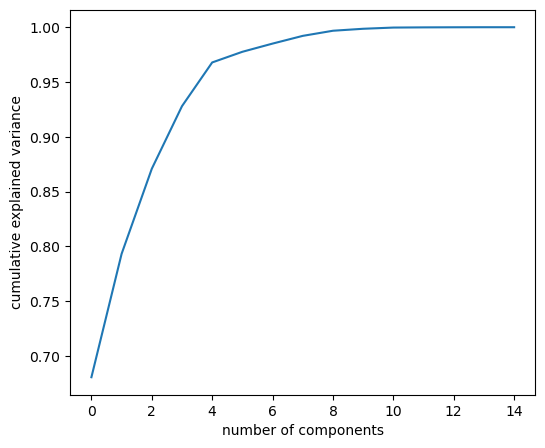

In [87]:
import numpy as np
pca = PCA().fit(df.loc[:, exclude_filter])
plt.figure(figsize=(6,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

Wykorzystanie parametru svd_solver.
Jeżeli 0 < n_components < 1 oraz svd_solver = 'full' to funkcja PCA wybiera liczbę komponentów, tak aby wielkość wariancji, którą należy wyjaśnić, była większa niż procent określony przez n_components.

In [88]:
pca = PCA(svd_solver='full', n_components=0.95)
principal_components = pca.fit_transform(df.loc[:, exclude_filter])
principal_df = pd.DataFrame(data=principal_components)
principal_df.head()

,0,1,2,3,4
0,0.077224,-0.478463,-0.087593,0.572624,-0.339989
1,-0.155617,-1.011251,-1.684940,-0.574601,-1.846124
2,5.806928,1.201618,4.169210,-0.470419,3.186590
3,-5.294890,2.552920,-1.466663,5.367300,1.030006
4,-0.352859,0.743658,3.437079,0.144013,-1.211092


### Przykład (iris)

<div style="display: flex; justify-content: center;">
<img src=".//Images//iris_watercolor.png" alt="Iris" width="600" height="120" style="margin: 10px;"/>
</div>

In [89]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [90]:
# Wczytanie danych
iris_df = pd.read_csv('./data/iris.csv')

# Zakładamy, że ostatnia kolumna to 'species'
X = iris_df.drop(columns=['species'])
y = iris_df['species']

In [91]:
# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [92]:
# Random Forest na oryginalnych danych
rf_original = RandomForestClassifier(random_state=42)
rf_original.fit(X_train, y_train)
y_pred_original = rf_original.predict(X_test)

In [93]:
print("Wyniki Random Forest na oryginalnych danych:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_original):.4f}")
print(classification_report(y_test, y_pred_original))

Wyniki Random Forest na oryginalnych danych:
Accuracy: 0.8889
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



In [94]:
# Skalowanie danych
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # !!!!!!!!!!!!!!!!

In [95]:
# PCA - redukcja do 2 wymiarów
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled) # !!!!!!!!!!!!!!!!!

In [96]:
# Random Forest na danych po PCA
rf_pca = RandomForestClassifier(random_state=42)
rf_pca.fit(X_train_pca, y_train)
y_pred_pca = rf_pca.predict(X_test_pca)

In [97]:
print("\nWyniki Random Forest na danych po PCA (2 komponenty):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_pca):.4f}")
print(classification_report(y_test, y_pred_pca))


Wyniki Random Forest na danych po PCA (2 komponenty):
Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



Jak widać, PCA zmniejszyła wymiar do dwóch, w dodatku wyznaczone dwa komponenty dały w tym przypadku lepsze wyniki modelu.

### Interpretacja graficzna (iris)

Wizualizację przeprowadzono dla całego zbioru iris.

In [98]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [99]:
%run PCA_functions_min.ipynb

Variable                          Type        Data/Info
-------------------------------------------------------
accuracy_score                    function    <function accuracy_score at 0x0000022D867A8220>
apply_scalers                     function    <function apply_scalers at 0x0000022D9783FA60>
bartlett_test                     function    <function bartlett_test at 0x0000022D90A7EC00>
calculate_bartlett_sphericity     function    <function calculate_bartl<...>ty at 0x0000022D904C45E0>
calculate_kmo                     function    <function calculate_kmo at 0x0000022D904C5C60>
classification_report             function    <function classification_<...>rt at 0x0000022D867A96C0>
load_iris                         function    <function load_iris at 0x0000022D902274C0>
load_wine                         function    <function load_wine at 0x0000022D90227380>
pca_biplot                        function    <function pca_biplot at 0x0000022D90AD3880>
pca_components                    function 

In [100]:
# Standaryzacja cech (średnia = 0, odchylenie standardowe = 1)
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

#### Wykres ładunków czynnikowych

Wykres przedstawia wektory połączone z początkiem układu współrzędnych, które to reprezentują zmienne pierwotne. Wektory te są umieszczone na płaszczyźnie wyznaczonej przez dwie wybrane składowe główne.

* **Współrzędne końca wektora** to odpowiadające im ładunki czynnikowe zmiennych.
* **Długość wektora** reprezentuje zasób informacyjny zmiennej pierwotnej, jaki niosą składowe główne wyznaczające układ współrzędnych. Im dłuższy wektor, tym wkład zmiennej pierwotnej w budowę składowych większy. W przypadku analizy opartej na macierzy korelacji ładunki są korelacjami pomiędzy zmiennymi pierwotnymi a składowymi, wówczas punkty wpadają do koła jednostkowego. Dzieje się tak dlatego, że współczynnik korelacji nie może przekroczyć jedynki. W rezultacie, im dana zmienna pierwotna leży bliżej brzegu tego koła, tym lepsza jest jej reprezentacja przez przedstawione główne składowe.
* **Znak współrzędnych końca wektora** czyli znak ładunku czynnikowego - wskazuje na dodatnią lub ujemną korelację zmiennej pierwotnej i składowych głównych tworzących układ współrzędnych. Jeżeli rozpatrujemy łącznie obie osie (2 składowe), wówczas zmienne pierwotne mogą być kwalifikowane do jednej z czterech kategorii, zależnie od kombinacji znaków (+/-) ich ładunków czynnikowych.
* **Kąt między wektorami** wskazuje na skorelowanie zmiennych pierwotnych:

  0 < α < 90&deg;: im kąt pomiędzy wektorami reprezentującymi zmienne pierwotne jest mniejszy tym silniejsza jest dodatnia korelacja pomiędzy tymi zmiennymi.

  α = 90&deg; - wektory te są prostopadłe, czyli zmienne pierwotne nie są skorelowane.

  90&deg; < α < 180&deg;: im kąt pomiędzy wektorami reprezentującymi zmienne pierwotne jest większy, tym silniejsza jest ujemna korelacja pomiędzy tymi zmiennymi.

**UWAGA**: Interpretacja kąta pomiędzy wektorami zmiennych na wykresie PCA (tzw. factor loadings plot) jest poprawna, jeśli spełnione są warunki:
* Liczba komponentów PCA jest równa liczbie zmiennych (pełna dekompozycja) lub:
* Pierwsze dwa komponenty wyjaśniają niemal 100% wariancji (np. powyżej 95%), dzięki czemu rzut na tę przestrzeń nie zniekształca relacji.
* Pamiętaj: PCA jest narzędziem redukcji wymiaru, a wykresy są wizualizacją uproszczoną, która może zniekształcać relacje.

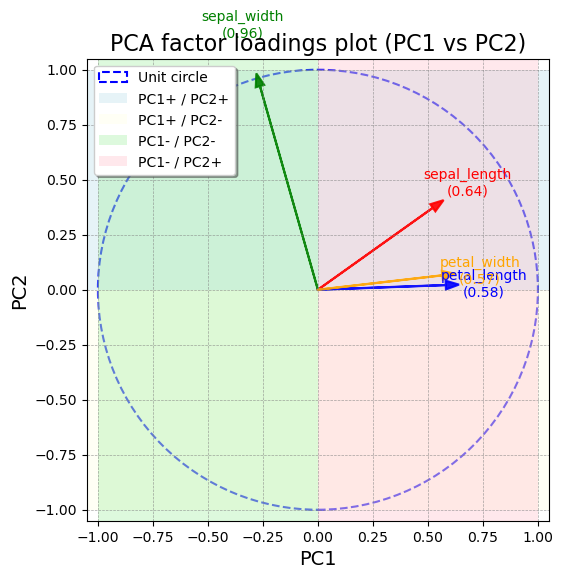

In [101]:
# Testowanie funkcji
ladunki_wynik = pca_components(df_scaled, n_components=2, components_to_plot=[1, 2], helper_lines=False, figsize=(6,6))

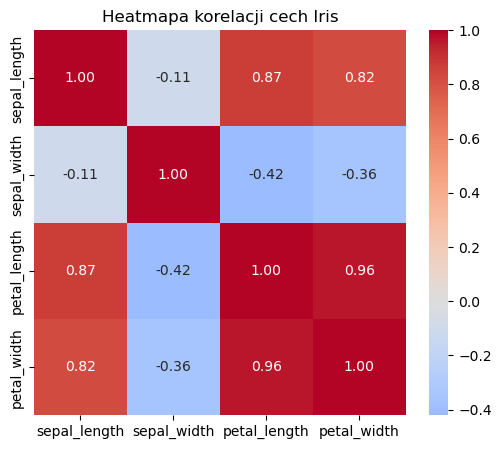

In [102]:
corr_matrix = df_scaled.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Heatmapa korelacji cech Iris")
plt.show()

In [103]:
vec1 = ladunki_wynik.loc['sepal_width', ['PC1', 'PC2']].values
vec2 = ladunki_wynik.loc['sepal_length', ['PC1', 'PC2']].values
cos_angle = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
angle_deg = np.degrees(np.arccos(cos_angle))
corr_value = corr_matrix.loc['sepal_width','sepal_length']
print(f"Korelacja między 'sepal length (cm)' i 'sepal width (cm)' wynosi: {corr_value:.4f} a kąt {angle_deg:.2f}°")


Korelacja między 'sepal length (cm)' i 'sepal width (cm)' wynosi: -0.1094 a kąt 70.40°


Mamy zatem zniekształcony lekko (w tym przypadku) obraz.

#### Biplot

Wykres przedstawia 2 serie danych umieszczone w układzie współrzędnych wyznaczonych przez 2 składowe główne. Serię pierwszą na wykresie stanowią dane z wykresu pierwszego (czyli wektory zmiennych pierwotnych) a serię drugą punkty przedstawiające poszczególne przypadki.

* **Współrzędne** punktów powinny być interpretowane jak wartości zestandaryzowane, tzn. współrzędne dodatnie wskazują na wartość wyższą od średniej wartości składowej głównej, ujemne na wartość niższą a im wyższa wartość bezwzględna tym dalej punkty znajdują się od średniej. Przy czym, jeśli na wykresie znajdują się obserwacje nietypowe - odstające, to mogą one zaburzać analizę i powinny być usunięte a analiza przeprowadzona ponownie.
* **Odległości między punktami** wskazują na podobieństwo przypadków - im bliżej (w zaczeniu odległości euklidesowej) zlokalizowane są względem siebie punkty, tym bardziej podobne informacje niosą porównywane przypadki.
* **Rzuty prostopadłe punktów na wektory** interpretujemy tak samo jak współrzędne punktów, czyli rzuty na osie z tym, że interpretacja dotyczy nie składowych głównych a zmiennych pierwotnych. Wartości umieszczone po stronie końca wektora są większe od średniej wartości zmiennej pierwotnej a wartości umieszczone na przedłużeniu wektora ale w kierunku przeciwnym są wartościami mniejszymi od średniej.

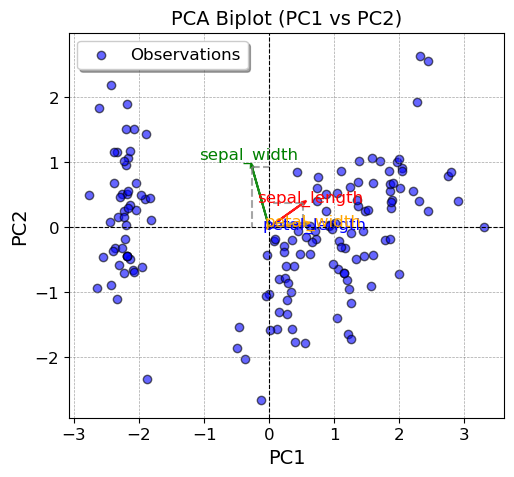

In [104]:
# Testowanie funkcji na danych PCA
ladunki_wynik, projekcje_wynik = pca_biplot(df_scaled, n_components=2, components_to_plot=[1, 2], helper_lines=True, figsize=(7,5))

#### Kryteria redukcji wymiarów

Nie istnieje jedno uniwersalne kryterium wyboru ilości składowych głównych. Dobrze jest wiec, aby przy wyborze kierować się kilkoma metodami.
* **Procent wyjaśnionej wariancji**: Liczba składowych głównych, jaką badacz powinien przyjąć zależy od tego, w jaki stopniu reprezentują one zmienne pierwotne, czyli zawartej w nich wariancji zmiennych pierwotnych. Wszystkie składowe główne niosą 100% wariancji zmiennych pierwotnych. Jeśli suma wariancji dla kilku pierwszych składowych stanowi znaczną część całkowitej wariancji zmiennych pierwotnych, wówczas te składowe główne mogą w zadowalającym stopniu zastąpić zmienne pierwotne. Przyjmuje się, że wariancja ta powinna zostać odzwierciedlona w składowych głównych w ponad 80 procentach.
* **Kryterium Kaisera**: Kryterium Kaisera mówi o tym, że składowe główne, które chcemy pozostawić do interpretacji powinny mieć przynajmniej taką samą wariancję jak dowolna wystandaryzowana zmienna pierwotna. W związku z tym, że wariancja każdej wystandaryzowanej zmiennej pierwotnej wynosi 1, to według kryterium Kaisera ważne są tylko składowe główne, których wartość własna przekracza lub jest bliska wartości 1.
* **Wykres osypiska**: Na wykresie tym przedstawione jest tempo spadku wartości własnych, czyli procentu wyjaśnionej wariancji.
<div style="display: flex; justify-content: center;">
<img src=".//Images//wykres_PCA_osypisko_opis.png" alt="osypisko" width="600" height="120" style="margin: 10px;"/>
</div>
Moment na wykresie, w którym proces ten stabilizuje się i linia malejąca przechodzi w poziomą to tzw. koniec osypiska (koniec osypywania się informacji o zmiennych pierwotnych, jaką niosą składowe główne). Składowe znajdujące się na prawo od punktu kończącego osypisko reprezentują znikomą wariancję i przedstawiają w większości losowy szum.

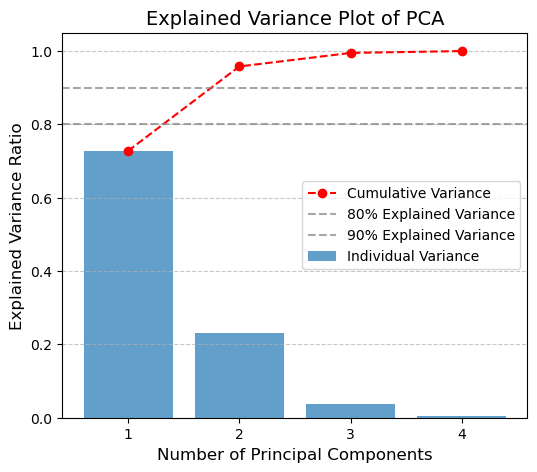

,Component,Explained Variance,Cumulative Variance
0,1,0.727705,0.727705
1,2,0.230305,0.958010
2,3,0.036838,0.994848
3,4,0.005152,1.000000


In [105]:
# Generate Explained Variance Plot
explained_variance_results = pca_explained_variance_plot(df_scaled, max_components=10, figsize=(6,5))
explained_variance_results

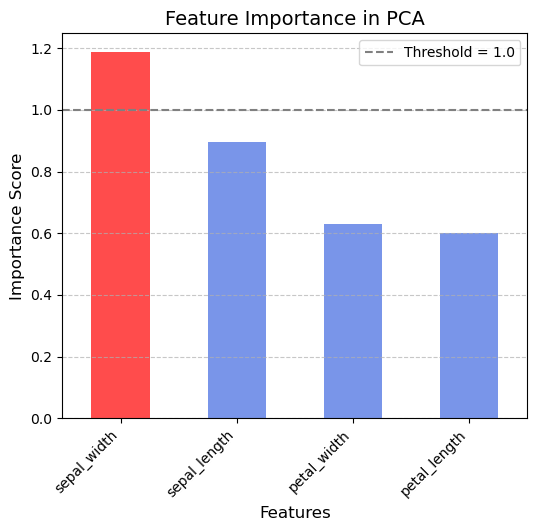

In [106]:
# Generate Feature Importance Plot for the large dataset with a threshold
feature_importance_results = pca_feature_importance(df_scaled, num_components=2, threshold=1.0, figsize=(6,5))

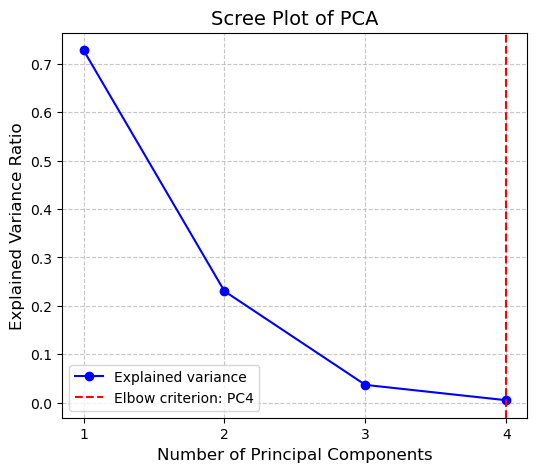

In [107]:
# Testing the function with sample PCA data
scree_plot_results = pca_scree_plot(df_scaled, max_components=10, figsize=(6,5))

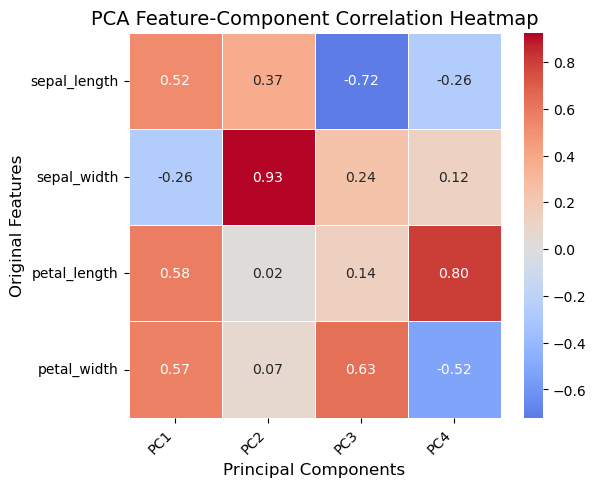

In [108]:
# Generate PCA correlation heatmap for the large dataset
pca_correlation_results = pca_correlation_heatmap(df_scaled, num_components=4, figsize=(6,5))

#### Wyznaczenie składowych głównych

Gdy zdecydujemy ilu składowych głównych będziemy potrzebować, możemy przystąpić do ich wygenerowania. W przypadku składowych głównych powstałych w oparciu o macierz korelacji składowe główne są wyliaczne jako kombinacja liniowa wystandaryzowanych zmiennych pierwotnych. Jeśli natomiast składowe główne powstały w oparciu o macierz kowariancji, wówczas są wyliaczne jako kombinacja liniowa wycentrowanych względem średniej zmiennych pierwotnych.

Otrzymane w ten sposób składowe główne stanowią nowe zmienne o pewnych zaletach. Przede wszystkim zmienne te nie są współliniowe. Zwykle jest ich mniej niż zmiennych pierwotnych, czasem znacznie mniej, a niosą one tyle samo lub nieznacznie mniej informacji niż zmienne pierwotne. Są więc zmiennymi, które z powodzeniem mogą być wykorzystane w większości analiz wielowymiarowych.

* **Zasadność stosowania Analizy składowych głównych** Jeśli zmienne nie są skorelowane (współczynnik korelacji Pearsona jest bliski 0), to wówczas przeprowadzanie analizy składowych głównych nie ma sensu. W takiej sytuacji bowiem każda zmienna stanowi już odrębną składową.
    * **Test Bartletta** Test ten wykorzystywany jest do weryfikacji hipotezy o tym, że współczynniki korelacji pomiędzy zmiennymi są zerowe (czyli macierz korelacji jest macierzą jednostkową).
    * **Współczynnik Kaisera-Mayera-Olkina**: Współczynnik ten wykorzystywany jest do sprawdzania stopnia skorelowania zmiennych pierwotnych, czyli siły dowodów świadczących na rzecz sensowności przeprowadzania analizy składowych głównych. Wartość współczynnika Kaisera należy do przedziału < 0, 1 >, gdzie wartości niskie świadczą o braku podstaw do przeprowadzania analizy składowych głównych, a wartości wysokie są przesłanką do przeprowadzania tej analizy.

**Wzór na test Bartletta:**
$$
\chi^2 = -\left( n - 1 - \frac{2p + 5}{6} \right) \cdot \ln(\det(R))
$$

gdzie: 

- $n$ — liczba obserwacji,  
- $p$ — liczba zmiennych,  
- $R$ — macierz korelacji,  
- $det(R)$ — wyznacznik macierzy korelacji.

In [109]:
import numpy as np
from scipy.stats import chi2

In [110]:
# Obliczenie testu Bartletta na podstawie macierzy korelacji
def bartlett_test(corr_matrix, n_samples):
    p = corr_matrix.shape[0]  # liczba zmiennych
    det_corr = np.linalg.det(corr_matrix)  # wyznacznik macierzy korelacji
    
    chi_square = -(n_samples - 1 - (2*p + 5) / 6) * np.log(det_corr)
    doff = p * (p - 1) / 2  # stopnie swobody
    return chi_square, doff

# Parametry do testu
n_samples = iris_df.shape[0]
corr_matrix = iris_df.drop(columns=['species']).corr()

# Obliczenie testu
chi_square_value, doff = bartlett_test(corr_matrix, n_samples)

# Obliczenie p-value
p_value = chi2.sf(chi_square_value, doff)

print(f"Chi-square: {chi_square_value:.2f}")
print(f"Degrees of freedom: {doff}")
print(f"P-value: {p_value:.6f}")

Chi-square: 706.36
Degrees of freedom: 6.0
P-value: 0.000000


**Interpretacja**:
* Test Bartletta sprawdza hipotezę zerową:
> **H₀:** macierz korelacji jest macierzą jednostkową (brak korelacji między zmiennymi).  
> **H₁:** przynajmniej niektóre współczynniki korelacji różnią się od zera.  

* Wartość statystyki chi-kwadrat jest bardzo wysoka, co oznacza silne odrzucenie hipotezy H₀.  
* Dla takiego p-value (przy tak dużej statystyce będzie bardzo bliskie 0), również wyszło < 0.05, co pozwala odrzucić hipotezę o braku korelacji.  

**Wniosek:** zmienne w zbiorze iris są istotnie skorelowane i warto przeprowadzić PCA.

**factor_analyzer** to biblioteka Pythona służąca do przeprowadzania analizy czynnikowej oraz związanych z nią testów statystycznych i obliczeń.

* **pip install factor_analyzer**

In [111]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

In [112]:
# Przygotowanie danych (np. iris bez kolumny gatunków)
iris_numeric = iris_df.drop(columns=['species'])

# Obliczenie testu Bartletta
chi_square_value, p_value = calculate_bartlett_sphericity(iris_numeric)

# Obliczenie stopni swobody
p = iris_numeric.shape[1]
doff = p * (p - 1) / 2

print(f"Chi-square: {chi_square_value:.2f}")
print(f"Degrees of freedom: {doff}")
print(f"P-value: {p_value:.6f}")

Chi-square: 706.36
Degrees of freedom: 6.0
P-value: 0.000000


In [113]:
from factor_analyzer.factor_analyzer import calculate_kmo

In [114]:
# Obliczenie wartości KMO
kmo_all, kmo_model = calculate_kmo(iris_df.drop(columns=['species']))
print(f"KMO (dla całego modelu): {kmo_model:.4f}")

KMO (dla całego modelu): 0.5364


* **Interpretacja wartości KMO:**
| KMO           | Ocena użyteczności analizy czynnikowej/PCA |
|---------------|---------------------------------------------|
| > 0.9         | Doskonała                                   |
| 0.8 – 0.9     | Bardzo dobra                                |
| 0.7 – 0.8     | Dobra                                       |
| 0.6 – 0.7     | Umiarkowana                                 |
| 0.5 – 0.6     | Marginalna                                  |
| < 0.5         | Nieodpowiednia — nie zaleca się PCA         |

## Bibliografia

* Przekleństwo wielowymiarowości i techniki redukcji wymiarów: https://miroslawmamczur.pl/przeklenstwo-wielowymiarowosci-i-jakie-sa-techniki-redukcji-wymiarow/

* Na czym polega analiza składowych głównych (PCA)? https://miroslawmamczur.pl/na-czym-polega-analiza-skladowych-glownych-pca/

* Analiza składowych głównych https://pqstat.pl/?mod_f=test_pca

i inne: 

* Jak działa metoda redukcji wymiarów t-SNE? https://miroslawmamczur.pl/jak-dziala-metoda-redukcji-wymiarow-t-sne/

* https://pub.towardsai.net/principal-component-analysis-pca-with-python-examples-tutorial-67a917bae9aa

* https://www.analyticsvidhya.com/blog/2016/03/pca-practical-guide-principal-component-analysis-python/